## Summary

This analysis compares the scaling behavior of three different sparse matrices across various thread counts. The plots use distinct line styles to differentiate between matrices:

- **Solid line (-)**: First matrix
- **Dashed line (--)**: Second matrix  
- **Dotted line (:)**: Third matrix

Key observations from the comparison plots:
- **Runtime**: Shows how execution time changes with thread count
- **GFLOPS**: Displays computational throughput scaling
- **Speedup**: Compares actual vs ideal scaling efficiency
- **Memory**: Tracks memory allocation patterns

All comparison plots have been saved to the `results/` directory.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Set matplotlib style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 2. Load Benchmark CSV Files

In [2]:
# Find all benchmark result CSV files
results_dir = 'results'
csv_files = sorted(glob.glob(os.path.join(results_dir, 'benchmark_results_*.csv')))

print(f"Found {len(csv_files)} benchmark files:")
for f in csv_files:
    print(f"  - {f}")

# Load all CSV files into a dictionary
dataframes = {}
for csv_file in csv_files:
    # Extract matrix name from filename
    matrix_name = os.path.basename(csv_file).replace('benchmark_results_', '').replace('.csv', '')
    dataframes[matrix_name] = pd.read_csv(csv_file)
    print(f"\nLoaded {matrix_name}: {len(dataframes[matrix_name])} records")
    print(f"  Matrix dimensions: {dataframes[matrix_name]['N'].iloc[0]} × {dataframes[matrix_name]['N'].iloc[0]}")
    print(f"  NNZ: {dataframes[matrix_name]['NNZ'].iloc[0]}")

Found 3 benchmark files:
  - results/benchmark_results_abb313.csv
  - results/benchmark_results_bcsstk30.csv
  - results/benchmark_results_pkustk14.csv

Loaded abb313: 3 records
  Matrix dimensions: 313 × 313
  NNZ: 1557

Loaded bcsstk30: 3 records
  Matrix dimensions: 28924 × 28924
  NNZ: 2043492

Loaded pkustk14: 3 records
  Matrix dimensions: 151926 × 151926
  NNZ: 14836504


## 3. Parse and Organize Data

In [3]:
# Define line styles for different matrices
line_styles = {
    list(dataframes.keys())[0]: '-',      # Solid line
    list(dataframes.keys())[1]: '--',     # Dashed line
    list(dataframes.keys())[2]: ':',      # Dotted line
}

# Define colors for better distinction
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

print("Line styles assigned to matrices:")
for i, (matrix, style) in enumerate(line_styles.items()):
    print(f"  {matrix}: {style} (color: {colors[i]})")

Line styles assigned to matrices:
  abb313: - (color: #1f77b4)
  bcsstk30: -- (color: #ff7f0e)
  pkustk14: : (color: #2ca02c)


## 4. Plot Runtime Comparison

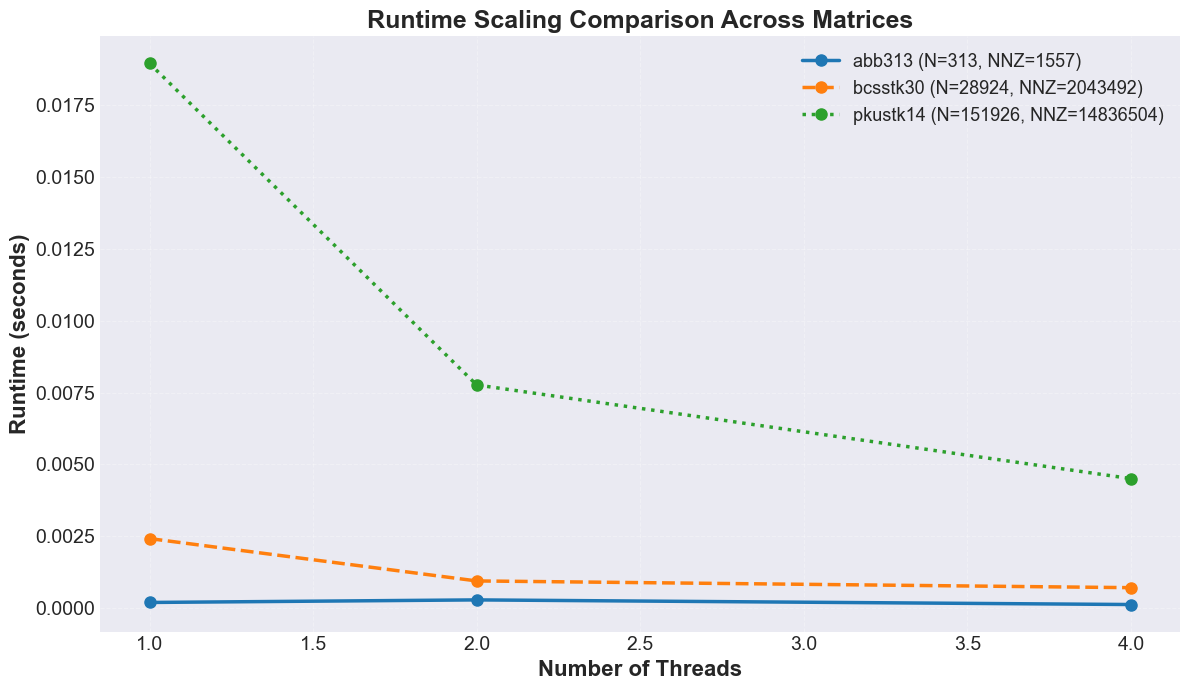

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

for i, (matrix_name, df) in enumerate(dataframes.items()):
    # Sort by threads for proper line plotting
    df_sorted = df.sort_values('Threads')
    
    ax.plot(
        df_sorted['Threads'], 
        df_sorted['AvgTime_s'],
        linestyle=line_styles[matrix_name],
        marker='o',
        color=colors[i],
        linewidth=2.5,
        markersize=8,
        label=f"{matrix_name} (N={df_sorted['N'].iloc[0]}, NNZ={df_sorted['NNZ'].iloc[0]})"
    )

ax.set_xlabel("Number of Threads", fontsize=16, fontweight='bold')
ax.set_ylabel("Runtime (seconds)", fontsize=16, fontweight='bold')
ax.set_title("Runtime Scaling Comparison Across Matrices", fontsize=18, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(fontsize=13, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('results/comparison_runtime.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Plot GFLOPS Comparison

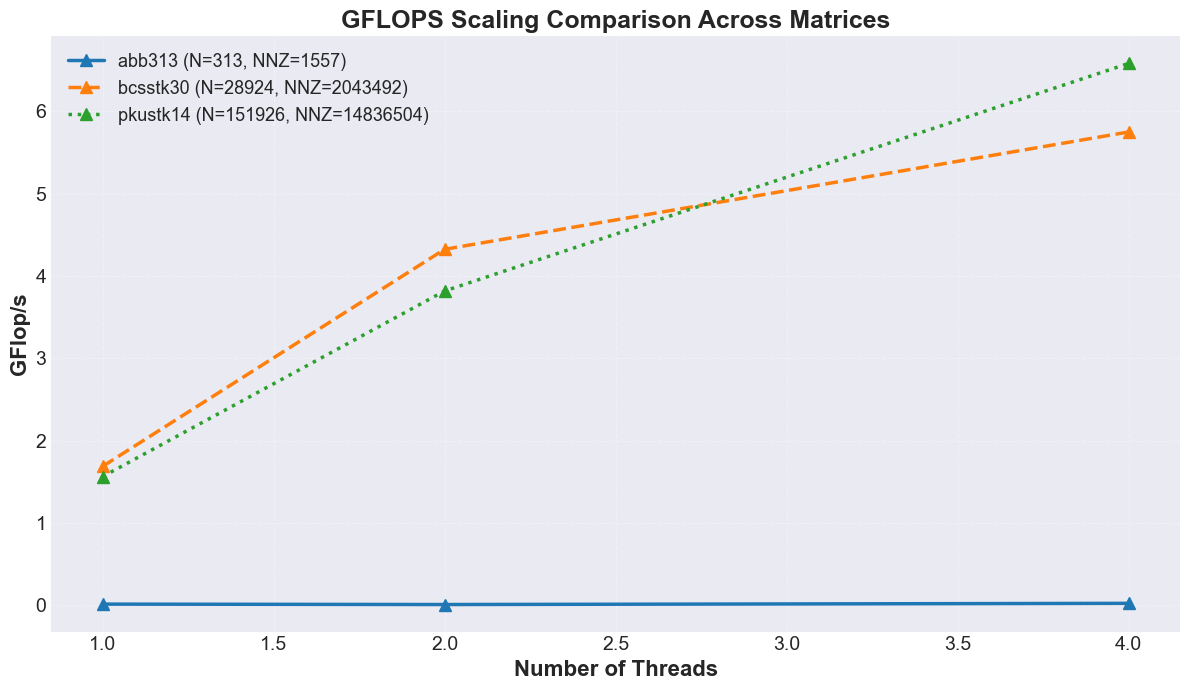

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

for i, (matrix_name, df) in enumerate(dataframes.items()):
    df_sorted = df.sort_values('Threads')
    
    ax.plot(
        df_sorted['Threads'], 
        df_sorted['GFlops'],
        linestyle=line_styles[matrix_name],
        marker='^',
        color=colors[i],
        linewidth=2.5,
        markersize=8,
        label=f"{matrix_name} (N={df_sorted['N'].iloc[0]}, NNZ={df_sorted['NNZ'].iloc[0]})"
    )

ax.set_xlabel("Number of Threads", fontsize=16, fontweight='bold')
ax.set_ylabel("GFlop/s", fontsize=16, fontweight='bold')
ax.set_title("GFLOPS Scaling Comparison Across Matrices", fontsize=18, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(fontsize=13, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('results/comparison_gflops.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Plot Speedup Comparison

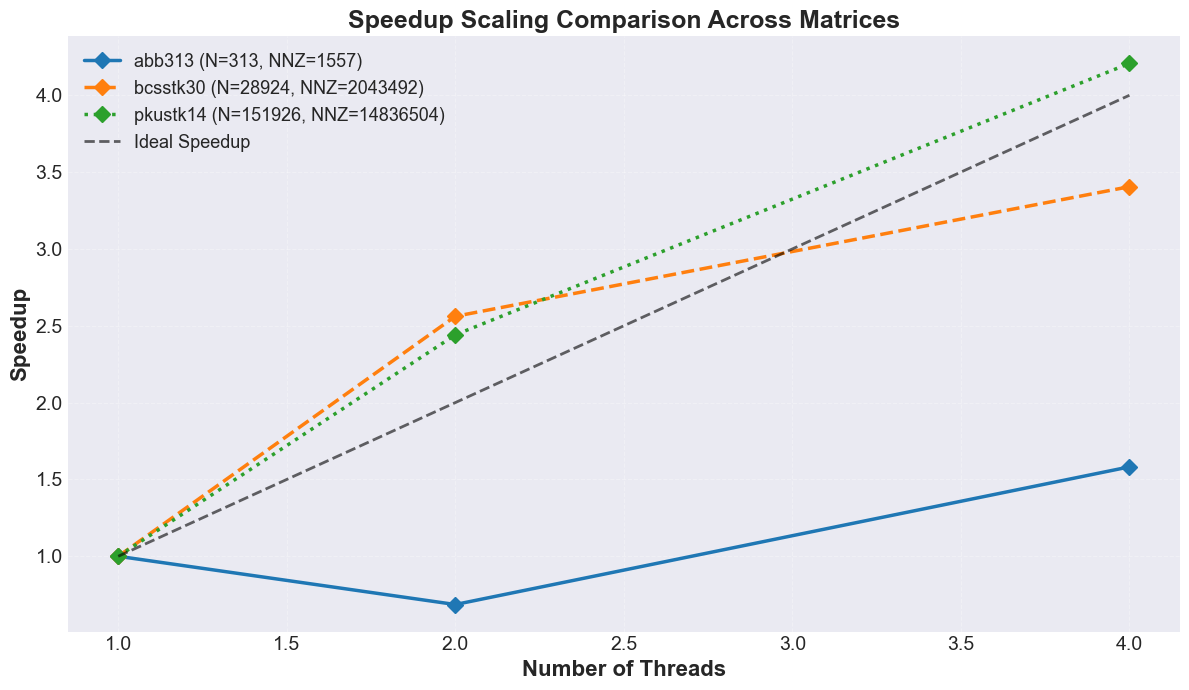

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))

for i, (matrix_name, df) in enumerate(dataframes.items()):
    df_sorted = df.sort_values('Threads')
    
    baseline = df_sorted[df_sorted['Threads'] == 1]['AvgTime_s'].values[0]
    speedup = baseline / df_sorted['AvgTime_s'].values
    
    ax.plot(
        df_sorted['Threads'], 
        speedup,
        linestyle=line_styles[matrix_name],
        marker='D',
        color=colors[i],
        linewidth=2.5,
        markersize=8,
        label=f"{matrix_name} (N={df_sorted['N'].iloc[0]}, NNZ={df_sorted['NNZ'].iloc[0]})"
    )

# Add ideal speedup line
threads = sorted(dataframes[list(dataframes.keys())[0]]['Threads'].unique())
ax.plot(threads, threads, 'k--', linewidth=2, alpha=0.6, label='Ideal Speedup')

ax.set_xlabel("Number of Threads", fontsize=16, fontweight='bold')
ax.set_ylabel("Speedup", fontsize=16, fontweight='bold')
ax.set_title("Speedup Scaling Comparison Across Matrices", fontsize=18, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(fontsize=13, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('results/comparison_speedup.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Plot Memory Allocation Comparison

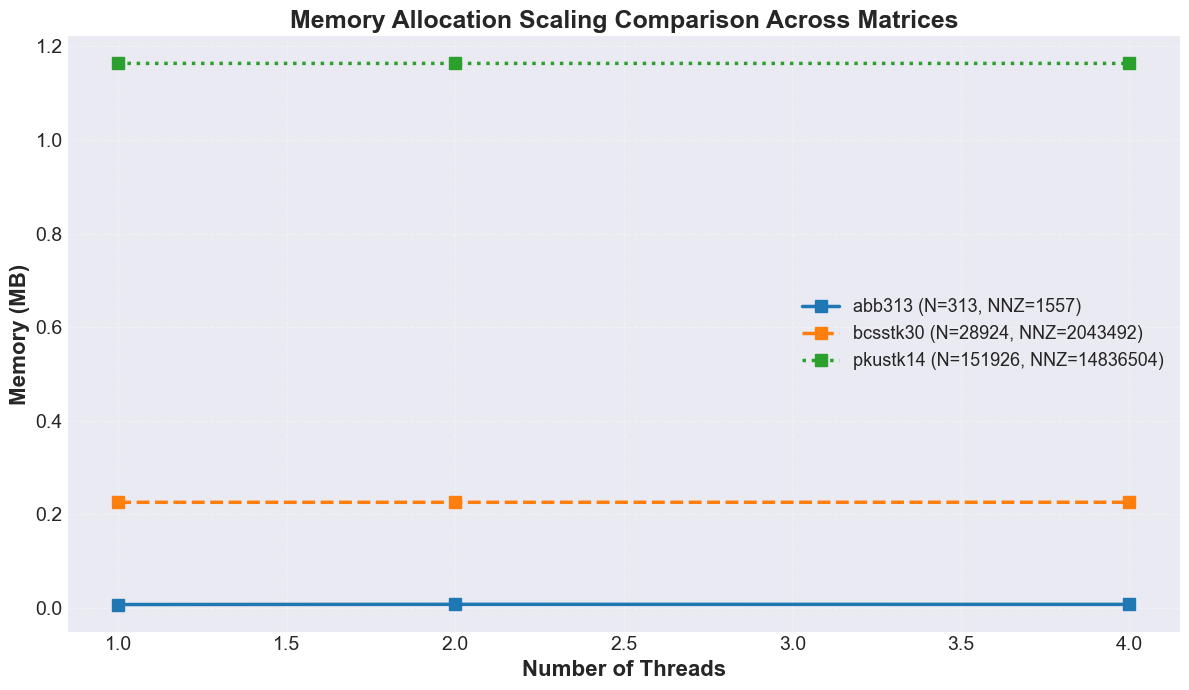

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

for i, (matrix_name, df) in enumerate(dataframes.items()):
    df_sorted = df.sort_values('Threads')
    
    ax.plot(
        df_sorted['Threads'], 
        df_sorted['Memory_MB'],
        linestyle=line_styles[matrix_name],
        marker='s',
        color=colors[i],
        linewidth=2.5,
        markersize=8,
        label=f"{matrix_name} (N={df_sorted['N'].iloc[0]}, NNZ={df_sorted['NNZ'].iloc[0]})"
    )

ax.set_xlabel("Number of Threads", fontsize=16, fontweight='bold')
ax.set_ylabel("Memory (MB)", fontsize=16, fontweight='bold')
ax.set_title("Memory Allocation Scaling Comparison Across Matrices", fontsize=18, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(fontsize=13, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('results/comparison_memory.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

This analysis compares the scaling behavior of three different sparse matrices across various thread counts. The plots use distinct line styles to differentiate between matrices:

- **Solid line (-)**: First matrix
- **Dashed line (--)**: Second matrix  
- **Dotted line (:)**: Third matrix

Key observations from the comparison plots:
- **Runtime**: Shows how execution time changes with thread count
- **GFLOPS**: Displays computational throughput scaling
- **Speedup**: Compares actual vs ideal scaling efficiency
- **Memory**: Tracks memory allocation patterns

All comparison plots have been saved to the `results/` directory.